# DECIPHER Summer School 2025, Bilbao - DIVACoast.jl
by Global Climate Forum, Berlin 2025

---

## What is DIVACoast.jl? 

`DIVACoast.jl` is a package for the programming language Julia. The package is currently under development and designed to provide a broad toolset for **coastal risk & adapatation assessment**. The key concept of `DIVACoast.jl` is the concept of risk. Following the definition of the Intergovernmental Panel on Climate Change (IPCC), risk constituted by the three components of hazard, exposure and vulnerability (Oppenheimer et al., 2019; Wong et al., 2014). While on the long run the package is meant to serve multiple coastal risks including the risk of flooding, erosion, salinity intrusion and wetland change, the current release concentrates on flood risk.

## What will you learn in this session?
1. Coastal Risk assessment using DIVACoast.jl
2. Flood Exposure assessment
    - calculate exposure using `HypsometricProfiles`
    - simulate socio-economic developments
3. Flood Damage calculation
    - Depth Damage Functions
    - assess expected damages
4. Flood adaptation
    - Hard defences
    - Accommodation 
    - Nature Based Solutions

---


## Setup

### On Google Colab

In [ ]:
run(`sh -c "rm DIVACoast.jl -rf && rm DIVACoastColab -rf && git clone https://github.com/GlobalClimateForum/DIVACoastColab.git && git clone https://github.com/GlobalClimateForum/DIVACoast.jl.git"`)

then...

In [ ]:
cd("/content")
using Pkg; Pkg.activate("./DIVACoastColab/"); Pkg.instantiate() # Requirements
cd("./DIVACoast.jl"); include("./src/DIVACoast.jl"); using .DIVACoast # Load DIVACoast.jl

### Load Required Packages

In [2]:
using Plots
using DataFrames

---

## Exposure assessment

### What is a Hypsometric Profile?
Currently the main way to represent exposure in DIVACoast.jl is as `HypsometricProfile`. This is a special kind of coastal profile that allows for a very efficient computation of flood damages, which is beneficial for running large number of damage assessments as, e.g., required for many economic questions that involve optimization.

![Hypsometric Profile](./fig_creating_hypsometric_profiles.gif)

### Hypsometric Profiles

For this session we pre-calculated `HypsometricProfile` around Europe. You can load them using:

In [ ]:
testdata    = "./testdata/hpfs_europe.jld2"
hypsometric_profiles = DIVACoast.load(testdata, Dict{Int32, HypsometricProfile{Float32}})

┌ Info: Loaded Dict{Int32, HypsometricProfile{Float32}} created at 2025-07-01T19:01:49.500
└ @ Main.DIVACoast c:\Users\Lars\Work\Global_Climate_Forum\DIVA\DIVACoast\src\io\jld\jld_load.jl:70


Dict{Int32, HypsometricProfile{Float32}} with 19547 entries:
  75664 => …
  32230 => …
  37100 => …
  61133 => …
  64632 => …
  60623 => …
  66578 => …
  37276 => …
  52093 => …
  59322 => …
  61392 => …
  47756 => …
  28804 => …
  56860 => …
  55097 => …
  50328 => …
  27640 => …
  53707 => …
  29661 => …
  ⋮     => ⋮

Each floodplain is associated with a `HypsometricProfile`. You can get a floodplain of interest by copying the floodplain ID from this **[map](https://globalclimateforum.github.io/DIVACoastExplorer/)**. <br> **Note:** The flooplain outlines in the map are simplified in order to visualize them in a efficient manner, they do not reflect the real floodplain outlines accurate.

In [4]:
floodplain = hypsometric_profiles[75804]

┌ HypsometricProfile
├ Width: 57.924213 km
├ Elevation: -5.0 up to 20.0m at 251 increments
├ Cum. area (maximum): 134.33258km^2
└ Exposures:
  ├ population: 251 values from 0.0 to 17090.89
  ├ assets: 251 values from 0.0 to 1.8341341e9

... and plot it.

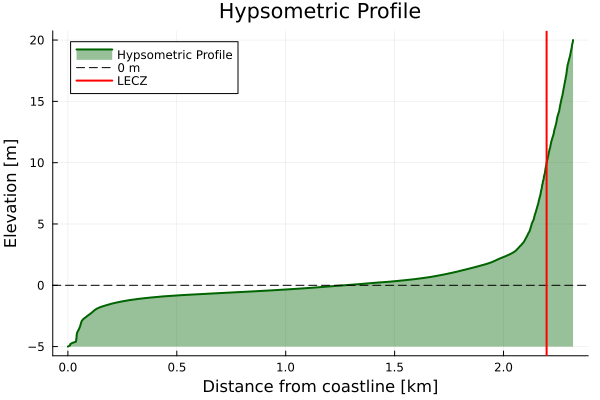

In [5]:
plot(floodplain)

to inspect the values you can convert the `HypsometricProfile` to a `DataFrame`:

In [6]:
floodplain_df = DataFrame(floodplain)

Row,elevation,cumulativeArea,width,population,assets
,Float32,Float32,Float32,Float32,Float32
1,-5.0,0.0,57.9242,0.0,0.0
2,-4.9,0.572212,57.9242,0.216805,23266.7
3,-4.8,0.617737,57.9242,0.265261,28466.9
4,-4.7,1.17717,57.9242,0.265691,28513.1
5,-4.6,2.12702,57.9242,1.21498,1.30387e5
6,-4.5,2.18555,57.9242,1.25341,1.34511e5
7,-4.4,2.23758,57.9242,1.31534,1.41158e5
8,-4.3,2.2701,57.9242,2.02603,2.17426e5
9,-4.2,2.30913,57.9242,2.03067,2.17925e5


using the DataFrame you can plot the different exposure from the Hypsometric Profile.

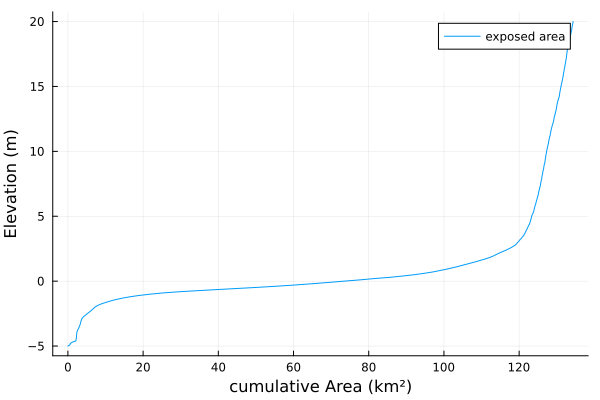

In [21]:
plot(floodplain_df.cumulativeArea, floodplain_df.elevation, 
    xlabel = "cumulative Area (km²)", ylabel = "Elevation (m)",
    label = "exposed area",
    legend = :topright)

### Exposure

The `exposure()` function is used to calculate the cumulative exposure below given water level (`wl`) for a hypsometric profile and for all exposure variables in a `HypsometricProfile` given a `InundationModel` (default is bathtub inundation). 

Arguments are:
- `hspf::HypsometricProfile{DT}`: The hypsometric profile with elevation, area and exposure data.
- `wl::Real`: The water level (surge height) for which exposure is calculated.
- `InundationModel`: inundation model used to calculate the propagation of the water level. The default is bathtub model.

#### Excercise 1

Use the `exposure()` function to calculate exposed assets and population under different flood scenarios: 1m, 2m , 3m ... 10m for your floodplain of interest.

In [8]:
# Type your code here

#### Solution Excercise 1

In [9]:
waterlevel_scenarios = 1:1:10 |> Vector{Float32}

exposures = map(wl -> wl =>  exposure(floodplain, wl), waterlevel_scenarios)
# exposures = map(wl -> wl => named(exposure, (floodplain, wl)), waterlevel_scenarios) # To get named exposures
exposures

10-element Vector{Pair{Float32, Tuple{Float32, Vector{Float32}}}}:
  1.0 => (101.85004, [3541.7642, 3.8008966f8])
  2.0 => (113.561775, [7611.964, 8.168892f8])
  3.0 => (119.67153, [11854.546, 1.2721883f9])
  4.0 => (122.072235, [12759.155, 1.3692681f9])
  5.0 => (123.32777, [12963.536, 1.3912014f9])
  6.0 => (124.45315, [13225.451, 1.4193094f9])
  7.0 => (125.3183, [13440.468, 1.4423841f9])
  8.0 => (126.05333, [13677.625, 1.4678351f9])
  9.0 => (126.69723, [13923.993, 1.494274f9])
 10.0 => (127.302124, [14182.731, 1.5220411f9])

#### Excercise 2

Modify the exposure in a `HypsometricProfile` you can use the [HypsometricProfile modifiers](https://globalclimateforum.github.io/DIVACoast.jl/exposure.html#Modifying-Hypsometric-Profiles) provided by `DIVACoast.jl`. Assume the following scenario: Until 2035 population declines by a factor of facotor of **0.85 above 5m** and population increases by a factor of **1.1 below 5m**.

In [10]:
# Type your code here

#### Solution Excercise 2

In [11]:
multiply_exposure_above!(floodplain, 5.0, :population,  0.85) # Applies a factor of 0.85 to population above 5m elevation
multiply_exposure_below!(floodplain, 5.0, :population, 1.1) # Applies a factor of 1.1 to population below 5m elevation

#### Excercise 3 (additional)

Simulate the following scenarios, subdividing changes for population and assets above and below 5m elevation:

| year | pop. change <5m | pop. change ≥5m | asset change <5m | asset change ≥5m |
| ---- | --------------- | --------------- | ---------------- | ---------------- |
| 2025 | 1.00            | 1.00            | 1.00             | 1.00             |
| 2030 | 0.98            | 0.98            | 1.02             | 1.00             |
| 2035 | 0.96            | 0.96            | 1.04             | 1.01             |
| 2040 | 0.94            | 0.94            | 1.06             | 1.02             |
| 2045 | 0.92            | 0.92            | 1.08             | 1.03             |
| 2050 | 0.90            | 0.90            | 1.10             | 1.04 

In [12]:
# Type your code here

---

## Damage assessment

In contrast to exposure, **damage** is dependend on **inundation depth**. Damage is a function of Flood Hazard, Flood Exposure, and Vulnerability. Hazard being extreme waterlevels, exposure the assets and population at risk, and  $vulnerability$ is represeneted by a Depth Damage Function. A Depth Damage function relates inundation depth to the share of the asset values that get damaged.

A common example is the following depth damage function

$$ 
vulnerability(\text{depth}) = \frac{\text{depth}}{\text{depth} + 1} 
$$

Implemented as:

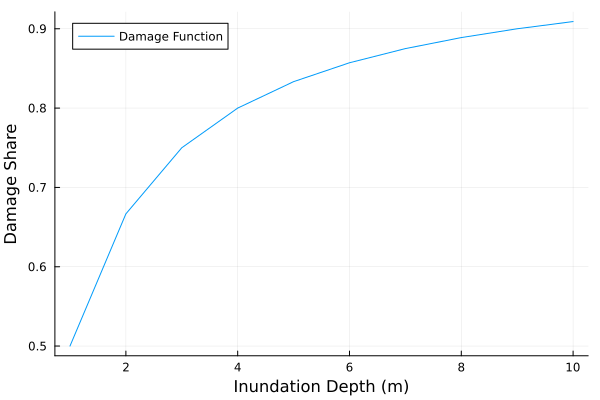

In [13]:
vulnerability = depth -> depth / (depth + 1)

depths = Vector{Float32}(1:1:10)
plot(depths, vulnerability.(depths), xlabel = "Inundation Depth (m)", ylabel = "Damage Share", label = "Damage Function",
    legend = :topleft)

To calulcate the damage within a floodplain for a given waterlevel you can use the `damage()` function:

```julia
damage(floodplain::HypsometricProfile, wl<:Real, exposure_variable::Symbol, ddf::Function)
```

#### Excercise 4

Calculate the damage to assets for different flood events (1.0m, 2.0m, ...) and compare it to the calculated exopsure (ex. 1). You can use the depth damage function $v$ from above or define your own. 


In [14]:
# Type your code here

#### Solution Excercise 4

In [15]:
#  Define waterlevel scenarions in 1m increments
waterlevel_scenarios =Vector{Float32}(1:1:10) 
# appply damage function to waterlevel scenarios
damages = map(wl -> wl => damage(floodplain, wl, :assets, vulnerability), waterlevel_scenarios) 

10-element Vector{Pair{Float32, Float32}}:
  1.0 => 1.6190378f8
  2.0 => 3.7319056f8
  3.0 => 6.926797f8
  4.0 => 9.231801f8
  5.0 => 1.04780224f9
  6.0 => 1.1295416f9
  7.0 => 1.1903384f9
  8.0 => 1.2405564f9
  9.0 => 1.2837367f9
 10.0 => 1.32441f9

---

## Protection

Coastal protection is characterised by reducing risk to coastal assets and populations by decreasing the hazard of sea level rise and coastal flooding. Physical infrastructure such as dikes, flood barriers or dams hold back extreme water levels. For the next excercise, let's consider the case of **Amsterdam  (id: 65562)**. Amsterdam is characterized by a large floodplain which is home to around 1 million people and high GDP per capita. In addition, large storm surges as are common in the North Sea as shown by the following extreme waterlevel distribution:


| return period   | waterlevel (m) |
| --------------- | -------------- |
| 1 in 1 year     | 2.84           |
| 1 in 5 years    | 3.20           |
| 1 in 10 years   | 3.33           |
| 1 in 25 years   | 3.47           |
| 1 in 50 years   | 3.56           |
| 1 in 100 years  | 3.63           |
| 1 in 500 years  | 3.80           |
| 1 in 1000 years | 3.87           |

To estimate the best fitting Generalized Extreme Value distribution (Gumbel, Frechet, Weibull) you can use the `estimate_gev_distribution()` as in the following: 

In [16]:
water_levels = [2.84, 3.20, 3.33, 3.47, 3.56, 3.63, 3.80, 3.87]
return_periods = [1, 5, 10, 25, 50, 100, 500, 1000]

# Covert return periods to cumulative probabilities
return_probs = map(rp -> 1 - (1 / rp), return_periods)

# Estimate GEV distribution parameters (assuming the function returns a distribution object)
gev_dist, _ = estimate_gev_distribution(water_levels, return_probs)

(Distributions.GeneralizedExtremeValue{Float64}(μ=3.080126752014836, σ=0.11608409571230302, ξ=0.0), 0.024618035120734162)

What do we do with this distribution? In order to assess optimal adaptation strategies today we need a measure of risk in the future. One such measure are **expected annual damages**.

With the `expected_damage` function you can compute the average annual damages for all possible flood events by integrating the damages with their probability of occurence. 

```julia
# Calculate expected annual damages to assets at a protection height of 2m
expected_damage(amsterdam_fp, gev_dist, 2.0, :assets, vulnerability)
```

#### Excercise 5 - Protection

The goal of this excercise is to implement a simple optimization problem in order to find the protection level at which expected annual damages for Amsterdam are halved (compared to a hypothetical scenario where Amsterdam is completely unprotected).

To solve this problem, in a first step calculate the expected annual damages to assets in Amsterdam (id : 65562) under the assumption that there is no protection in place. Second, assess at which protection level (flood return period) would expected annual damages be halved?

In [17]:
# Type your code here

#### Solution Excercise 5

In [22]:
amsterdam_fp = hypsometric_profiles[65562]

expected_damages_0 = expected_damage(amsterdam_fp, gev_dist, 0.0, :assets, vulnerability)

println("Expected damages at 0m protection level: ", expected_damages_0)

current_protection_level = 0.0
expected_damages = Inf

while expected_damages > expected_damages_0 / 2
    current_protection_level += 0.1
    expected_damages = expected_damage(amsterdam_fp, gev_dist, current_protection_level, :assets, vulnerability)
    println("Expected damages at protection level ", current_protection_level, "m: ", expected_damages)
end

println(current_protection_level)

Expected damages at 0m protection level: 6.3904063e10
Expected damages at protection level 0.1m: 6.3904027e10
Expected damages at protection level 0.2m: 6.3904047e10
Expected damages at protection level 0.30000000000000004m: 6.3904055e10
Expected damages at protection level 0.4m: 6.3904055e10
Expected damages at protection level 0.5m: 6.4135037e10
Expected damages at protection level 0.6m: 6.390402e10
Expected damages at protection level 0.7m: 6.3904043e10
Expected damages at protection level 0.7999999999999999m: 6.390405e10
Expected damages at protection level 0.8999999999999999m: 6.3904043e10
Expected damages at protection level 0.9999999999999999m: 6.3904047e10
Expected damages at protection level 1.0999999999999999m: 6.3904047e10
Expected damages at protection level 1.2m: 6.3904055e10
Expected damages at protection level 1.3m: 6.3903973e10
Expected damages at protection level 1.4000000000000001m: 6.390406e10
Expected damages at protection level 1.5000000000000002m: 6.390406e10
Expe

### Accomodation

Contrary to coastal protection measures, accomodation is often performed at the micro level and includes a range of architectural or institutional responses such as flood proofing or elevating buildings, uptake of insurance or policies to reduce the harm that floods cause. Unlike coastal protection, accomodation measures do not modify  flood hazard, but rather reduce the vulnerability of coastal populations and assets to flood impacts.


#### Excercise 6 - Accomodation

The purpose of this excercise is to implement a simple model of accomodation within the previous modeling framework. Which component of the risk model (hazard, exposure, vulnerability) would you modify to implement flood proofing of buildings of up to 1m? You can use the floodplain you previously selected or keep the Amsterdam example.

In [19]:
# Write your code here

#### Solution Excercise 6

In order to model a reduction of vulnerability you can modify the depth-damage function. For example you can define a new function that reduces the damage to 0 for inundation depths smaller or equal to 1m, such that

$$
vulnerability(depth) = 
\begin{cases}
0 & \text{if } depth < 1 \\
\frac{depth}{depth + 1} & \text{else}
\end{cases}
$$

In [20]:
# Depth-damage function that reduces the damage to 0 for inundation depths smaller or equal to 1m
vulnerability_reduced = depth -> depth <= 1 ? 0 : depth / (depth + 1)

# Apply the modified vulnerability function to the floodplain
damages_reduced = map(wl -> wl => damage(floodplain, wl, :assets, vulnerability_reduced), waterlevel_scenarios)

10-element Vector{Pair{Float32, Float32}}:
  1.0 => 1.0658624f8
  2.0 => 2.4561384f8
  3.0 => 5.3896365f8
  4.0 => 8.873547f8
  5.0 => 1.0406049f9
  6.0 => 1.1201847f9
  7.0 => 1.183107f9
  8.0 => 1.2322679f9
  9.0 => 1.276001f9
 10.0 => 1.315666f9

## Additional
So far, we have only used the default Inundation Model in DIVACoast.jl, the "Bathtub" Inundation. The Bathtub model is useful for modeling flooding across large regional scales or for testing a broad variety of adaptation strategies in a runtime-efficient manner. For certain adaptation strategies, such as the implementation of wetlands, you may want to consider attenuation. Therefore, DIVACoast offers the attenuated Bathtub model. You can pass the attenuated Bathtub model as a keyword argument to the `exposure()` and `damage()` functions. The `LinearDistanceAttenuatedInundation` model takes an attenuation value as a parameter (m/km attenuation).

```julia
damage(floodplain, wl, :assets, vulnerability, LinearDistanceAttenuatedInundation(0.1))
```